In [4]:
#status : à supprimer car même valeur pour toutes les lignes
#level
#page
#ItemInsession
#Method
#Song
#artist

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
dataset=pd.read_parquet("train.parquet")

In [6]:
df=dataset.copy()

In [7]:
df.shape

(17499636, 19)

In [8]:
df.shape

(17499636, 19)

In [9]:
df.head()

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
0,200,M,Shlok,paid,Johnson,1749042,1538352001000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",278,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,524.32934,Ich mache einen Spiegel - Dream Part 4,Popol Vuh,2018-10-01 00:00:01,2018-08-08 13:22:21
992,200,M,Shlok,paid,Johnson,1749042,1538352525000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",279,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,178.02404,Monster (Album Version),Skillet,2018-10-01 00:08:45,2018-08-08 13:22:21
1360,200,M,Shlok,paid,Johnson,1749042,1538352703000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",280,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,232.61995,Seven Nation Army,The White Stripes,2018-10-01 00:11:43,2018-08-08 13:22:21
1825,200,M,Shlok,paid,Johnson,1749042,1538352935000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",281,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,265.50812,Under The Bridge (Album Version),Red Hot Chili Peppers,2018-10-01 00:15:35,2018-08-08 13:22:21
2366,200,M,Shlok,paid,Johnson,1749042,1538353200000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",282,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,471.69261,Circlesong 6,Bobby McFerrin,2018-10-01 00:20:00,2018-08-08 13:22:21


In [10]:
df["status"].value_counts()
#donc toutes les lignes de notre dataset ont le même status, donc pas pertinet à regarder, il faut le supprimer


status
200    16020693
307     1461649
404       17294
Name: count, dtype: int64

In [11]:
df["level"].value_counts()

level
paid    13506659
free     3992977
Name: count, dtype: int64

In [12]:
level_map={"free":0, "paid": 1}
df["level"]=df["level"].map(level_map).fillna(0).astype(int)
level_features=df[["userId", "level"]]

In [13]:
level_features["level"].value_counts()

level
1    13506659
0     3992977
Name: count, dtype: int64

In [14]:
level_features.head()   # voici  notre nouvelle feature "level" prête à être mergée avec les autres features

,userId,level
0,1749042,1
992,1749042,1
1360,1749042,1
1825,1749042,1
2366,1749042,1


In [15]:
df["method"].value_counts()

method
PUT    16162688
GET     1336948
Name: count, dtype: int64

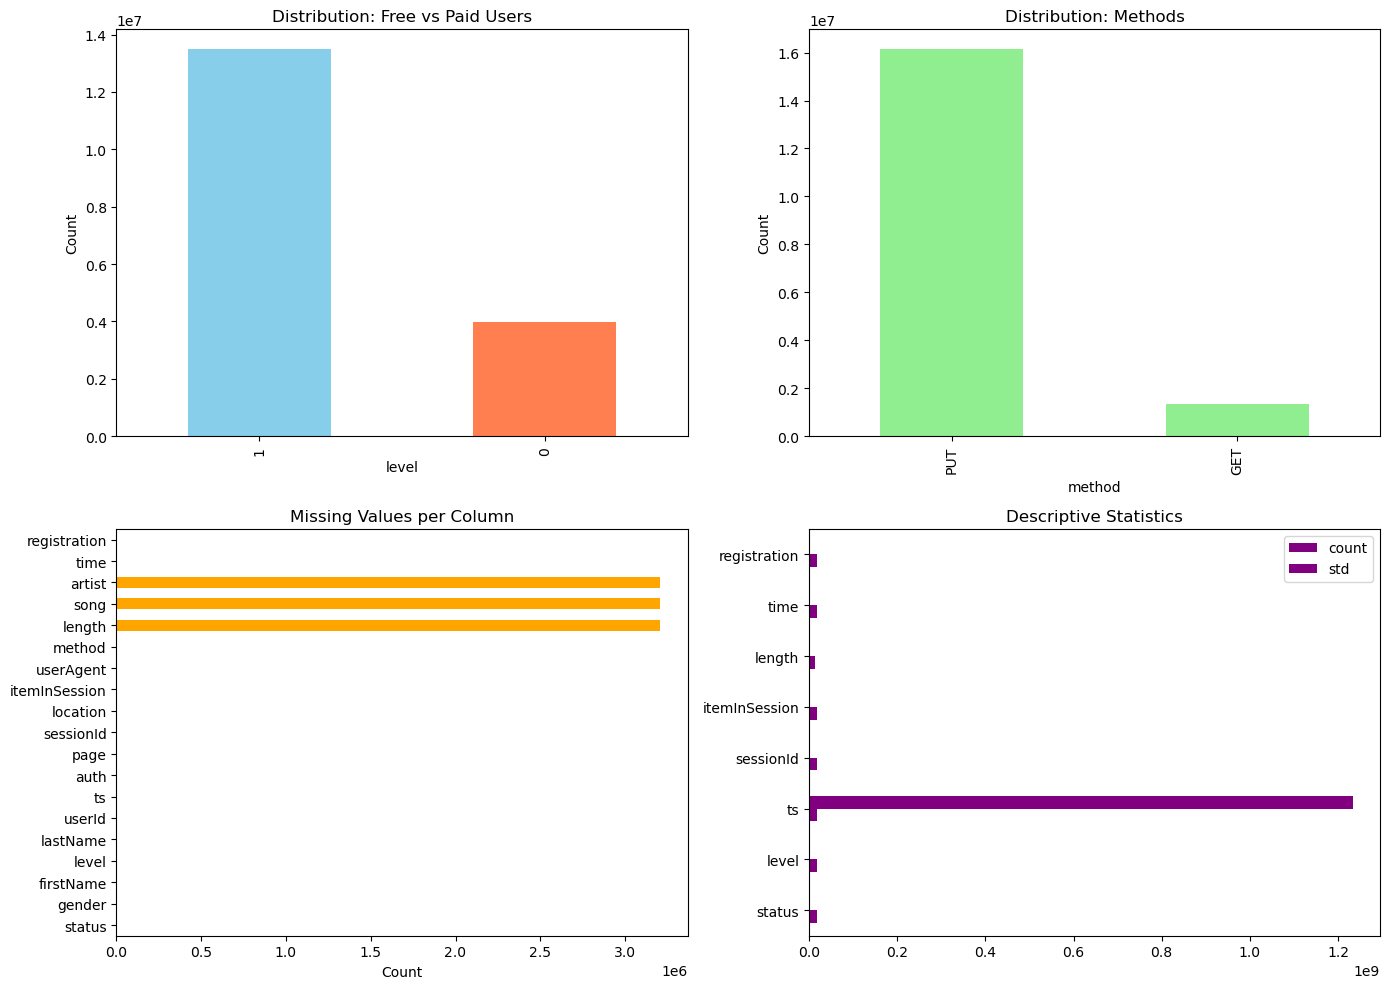

Shape: (17499636, 19)

Colonnes: ['status', 'gender', 'firstName', 'level', 'lastName', 'userId', 'ts', 'auth', 'page', 'sessionId', 'location', 'itemInSession', 'userAgent', 'method', 'length', 'song', 'artist', 'time', 'registration']

Types de données:
status                    int64
gender                   object
firstName                object
level                     int32
lastName                 object
userId                   object
ts                        int64
auth                     object
page                     object
sessionId                 int64
location                 object
itemInSession             int64
userAgent                object
method                   object
length                  float64
song                     object
artist                   object
time             datetime64[us]
registration     datetime64[us]
dtype: object


In [20]:
# Visualiser la distribution des variables clés
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution du level (free vs paid)
level_features["level"].value_counts().plot(kind='bar', ax=axes[0, 0], color=['skyblue', 'coral'])
axes[0, 0].set_title('Distribution: Free vs Paid Users')
axes[0, 0].set_ylabel('Count')

# 2. Distribution des méthodes
df["method"].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Distribution: Methods')
axes[0, 1].set_ylabel('Count')

# 3. Valeurs manquantes
df.isnull().sum().plot(kind='barh', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Missing Values per Column')
axes[1, 0].set_xlabel('Count')

# 4. Statistiques descriptives
df.describe().T.plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Descriptive Statistics')

plt.tight_layout()
plt.show()

# Afficher un résumé du dataset
print(f"Shape: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")
print(f"\nTypes de données:\n{df.dtypes}")

In [21]:
method_map={"PUT":0, "GET": 1}
df["method"]=df["method"].map(method_map).fillna(-1).astype(int)
method_features=df[["userId", "method"]]

In [22]:
method_features.head()  # voici notre nouvelle feature "method" prête à être mergée avec les autres features

,userId,method
0,1749042,0
992,1749042,0
1360,1749042,0
1825,1749042,0
2366,1749042,0


In [24]:
method_features["method"].value_counts()

method
0    16162688
1     1336948
Name: count, dtype: int64

In [31]:
page_features=pd.crosstab(df["userId"], df["page"])
page_features.head()

page,About,Add Friend,Add to Playlist,Cancel,Cancellation Confirmation,Downgrade,Error,Help,Home,Logout,NextSong,Roll Advert,Save Settings,Settings,Submit Downgrade,Submit Upgrade,Thumbs Down,Thumbs Up,Upgrade
userId,,,,,,,,,,,,,,,,,,,
1000025,1,30,53,1,1,18,1,8,77,26,1662,7,3,8,0,1,13,94,1
1000035,2,23,27,0,0,7,1,5,54,19,1266,6,1,7,0,1,15,117,5
1000083,0,6,8,1,1,2,0,2,21,14,501,8,0,5,0,1,2,21,3
1000103,0,0,1,0,0,1,0,0,6,2,57,3,0,0,0,1,1,2,1
1000164,2,17,24,0,0,10,1,4,40,11,847,20,1,5,0,1,6,38,1


In [32]:
df["itemInSession"].value_counts()

itemInSession
2       193405
3       191880
4       189705
5       186870
6       184049
         ...  
1374         2
1373         2
1328         2
1425         1
1426         1
Name: count, Length: 1427, dtype: int64

In [33]:
# Exemple : voir les actions d'une session
df[df['sessionId'] == 22683][['userId', 'sessionId', 'itemInSession', 'page', 'song']].head(10)


,userId,sessionId,itemInSession,page,song
0,1749042,22683,278,NextSong,Ich mache einen Spiegel - Dream Part 4
992,1749042,22683,279,NextSong,Monster (Album Version)
1360,1749042,22683,280,NextSong,Seven Nation Army
1825,1749042,22683,281,NextSong,Under The Bridge (Album Version)
2366,1749042,22683,282,NextSong,Circlesong 6
3271,1749042,22683,283,NextSong,Who Can Compare
3802,1749042,22683,284,NextSong,Angel Dust
6585,1749042,22683,285,NextSong,Sweet And Dandy
6675,1749042,22683,286,Downgrade,None
6961,1749042,22683,287,NextSong,On The Moon


## Analyse du lien entre downgrade (passage de "paid" à "free") et churn

Pour explorer si le passage du statut "paid" à "free" est lié au churn, il faut :

- Identifier les utilisateurs ayant effectué un downgrade (`page == "Downgrade"`).
- Définir le churn (par exemple, si l'utilisateur a une action "Cancellation Confirmation").
- Croiser ces deux informations pour voir si le downgrade précède ou accompagne le churn.

**Étapes à suivre :**
1. Créer une variable indiquant si l'utilisateur a effectué un downgrade.
2. Créer une variable indiquant si l'utilisateur a churné.
3. Calculer la proportion de churn parmi les utilisateurs ayant downgradé vs ceux qui n'ont pas downgradé.
4. Visualiser ou afficher les résultats.

Cela permettra de voir s'il existe une corrélation entre downgrade et churn.



**Résultats attendus :**
- Un tableau de contingence montrant la relation entre downgrade et churn.
- Un graphique comparant les taux de churn pour les deux groupes.
- Une analyse statistique (ex: chi-squared test) pour évaluer la significativité de la relation.

In [63]:


downgrade = (page_features['Downgrade'] > 0).astype(int)
downgrade_features = pd.DataFrame({'has_downgraded': downgrade})
downgrade_features.head()


,has_downgraded
userId,
1000025,1
1000035,1
1000083,1
1000103,1
1000164,1


In [66]:
has_churned=(page_features['Cancellation Confirmation']>0).astype(int)
churned_features=pd.DataFrame({"has_churned": has_churned})
churned_features.head()


,has_churned
userId,
1000025,1
1000035,0
1000083,1
1000103,0
1000164,0


In [68]:

merged_df=churned_features.join(downgrade_features, how='inner')

In [72]:
merged_df.head()
merged_df.groupby('has_churned')['has_downgraded'].agg(['mean', 'sum', 'count'])

,mean,sum,count
has_churned,,,
0,0.610196,9073,14869
1,0.728869,3113,4271


In [75]:
import matplotlib.pyplot as plt

# Contingency table: rows = has_downgraded (0/1), cols = has_churned (0/1)
contingency = pd.crosstab(merged_df['has_downgraded'], merged_df['has_churned'])

In [76]:
contingency

has_churned,0,1
has_downgraded,,
0,5796,1158
1,9073,3113


In [77]:
correlation = np.corrcoef(merged_df['has_downgraded'], merged_df['has_churned'])[0, 1]

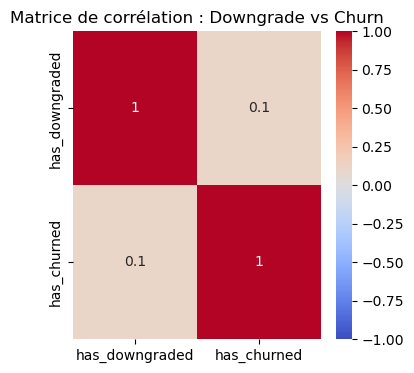

Table de contingence (rows = downgraded 0/1, cols = churned 0/1):
 has_churned        0     1
has_downgraded            
0               5796  1158
1               9073  3113 

Chi2 = 201.4933, p-value = 9.8621e-46, dof = 1
Table des effectifs attendus:
 has_churned               0            1
has_downgraded                          
0               5402.247962  1551.752038
1               9466.752038  2719.247962
Cramér's V = 0.1026  (tailles d'effet : ≈0.1 faible, 0.3 modéré, 0.5 fort)

Fisher exact test : oddsratio = 1.7173, p-value = 3.5472e-47


In [79]:
from scipy.stats import chi2_contingency, fisher_exact

# Trace la matrice de corrélation entre has_downgraded et has_churned
# puis réalise un test statistique (chi2 et Fisher pour 2x2) + effect size (Cramer's V)


# sous-ensemble des deux colonnes
cols = ['has_downgraded', 'has_churned']
corr_mat = merged_df[cols].corr()

# heatmap de la matrice de corrélation
plt.figure(figsize=(4, 4))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation : Downgrade vs Churn")
plt.show()

# contingency table (au cas où elle n'existerait pas déjà)
try:
    cont = contingency.copy()
except NameError:
    cont = pd.crosstab(merged_df['has_downgraded'], merged_df['has_churned'])

print("Table de contingence (rows = downgraded 0/1, cols = churned 0/1):\n", cont, "\n")

# Test du khi-deux
chi2, p_val, dof, expected = chi2_contingency(cont.values)
n = cont.values.sum()
cramers_v = (chi2 / (n * (min(cont.shape) - 1))) ** 0.5

print(f"Chi2 = {chi2:.4f}, p-value = {p_val:.4e}, dof = {dof}")
print("Table des effectifs attendus:\n", pd.DataFrame(expected, index=cont.index, columns=cont.columns))
print(f"Cramér's V = {cramers_v:.4f}  (tailles d'effet : ≈0.1 faible, 0.3 modéré, 0.5 fort)\n")

# Test exact de Fisher (utile pour 2x2) — renvoie oddsratio et p-value
if cont.shape == (2, 2):
    oddsratio, fisher_p = fisher_exact(cont.values)
    print(f"Fisher exact test : oddsratio = {oddsratio:.4f}, p-value = {fisher_p:.4e}")
else:
    print("Fisher exact test non effectué : la table n'est pas 2x2.")

In [80]:
df_autres=df.groupby('userId').agg({
    "song": 'nunique',
    "artist": 'nunique',
    "itemInSession": 'max',
})

In [81]:
df_autres


,song,artist,itemInSession
userId,,,
1000025,1468,1162,486
1000035,1154,916,228
1000083,478,427,171
1000103,57,56,53
1000164,778,660,215
...,...,...,...
1999781,2673,1890,679
1999847,316,289,266
1999848,919,758,172


In [ ]:
method_features=method_features.set_index('userId')


In [85]:
method_features

,method
userId,
1749042,0
1749042,0
1749042,0
1749042,0
1749042,0
...,...
1152881,0
1152881,1
1152881,0


In [86]:
level_features=level_features.set_index('userId')

In [87]:
level_features

,level
userId,
1749042,1
1749042,1
1749042,1
1749042,1
1749042,1
...,...
1152881,1
1152881,1
1152881,1


In [89]:
page_features

page,About,Add Friend,Add to Playlist,Cancel,Cancellation Confirmation,Downgrade,Error,Help,Home,Logout,NextSong,Roll Advert,Save Settings,Settings,Submit Downgrade,Submit Upgrade,Thumbs Down,Thumbs Up,Upgrade
userId,,,,,,,,,,,,,,,,,,,
1000025,1,30,53,1,1,18,1,8,77,26,1662,7,3,8,0,1,13,94,1
1000035,2,23,27,0,0,7,1,5,54,19,1266,6,1,7,0,1,15,117,5
1000083,0,6,8,1,1,2,0,2,21,14,501,8,0,5,0,1,2,21,3
1000103,0,0,1,0,0,1,0,0,6,2,57,3,0,0,0,1,1,2,1
1000164,2,17,24,0,0,10,1,4,40,11,847,20,1,5,0,1,6,38,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999781,6,51,86,0,0,19,5,19,120,40,3165,61,4,24,0,1,30,152,4
1999847,2,8,8,1,1,8,0,1,24,6,322,14,2,6,0,1,6,9,4
1999848,1,34,26,0,0,3,4,12,68,24,1004,77,3,10,1,1,12,57,14


In [90]:
level_features=level_features.reset_index('userId')

In [93]:
level_features=level_features.groupby('userId')['level'].max()

In [95]:
level_features=pd.DataFrame(level_features)
level_features

,level
userId,
1000025,1
1000035,1
1000083,1
1000103,1
1000164,1
...,...
1999781,1
1999847,1
1999848,1


In [96]:
method_features=pd.DataFrame(method_features.reset_index('userId').groupby('userId')['method'].max())
method_features

,method
userId,
1000025,1
1000035,1
1000083,1
1000103,1
1000164,1
...,...
1999781,1
1999847,1
1999848,1


In [97]:
Nelson_features=level_features.join(method_features, how='inner').join(page_features, how='inner').join(df_autres, how='inner').join(merged_df, how='inner')
Nelson_features

,level,method,About,Add Friend,Add to Playlist,Cancel,Cancellation Confirmation,Downgrade,Error,Help,...,Submit Downgrade,Submit Upgrade,Thumbs Down,Thumbs Up,Upgrade,song,artist,itemInSession,has_churned,has_downgraded
userId,,,,,,,,,,,,,,,,,,,,,
1000025,1,1,1,30,53,1,1,18,1,8,...,0,1,13,94,1,1468,1162,486,1,1
1000035,1,1,2,23,27,0,0,7,1,5,...,0,1,15,117,5,1154,916,228,0,1
1000083,1,1,0,6,8,1,1,2,0,2,...,0,1,2,21,3,478,427,171,1,1
1000103,1,1,0,0,1,0,0,1,0,0,...,0,1,1,2,1,57,56,53,0,1
1000164,1,1,2,17,24,0,0,10,1,4,...,0,1,6,38,1,778,660,215,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999781,1,1,6,51,86,0,0,19,5,19,...,0,1,30,152,4,2673,1890,679,0,1
1999847,1,1,2,8,8,1,1,8,0,1,...,0,1,6,9,4,316,289,266,1,1
1999848,1,1,1,34,26,0,0,3,4,12,...,1,1,12,57,14,919,758,172,0,1
